# Option B Exploration

This notebook contains the exploration component for Option B, due the week after the main notebook. Choose something related to the topics covered in the main notebook and build something creative or interesting.

_For this notebook some helpful staring points for the extension include:_
* **Edge/lane detection using your own images:** Apply edge detection to your own photos. Where does it go wrong? Why might that be the case? Are there other edge detection algorithms that work better?
* **Enhancing the edge detection algorithm** Can you improve the edge detection algorithm somewhere?

For more detailed instructions, please see the [Project 1 Guidelines](https://docs.google.com/document/d/1_yLzSePaVH2OrQgzZsu-1sZ4ez1Da9_tFzZFM3LCarQ/edit?usp=sharing)


## Review of current methods (10 points)
Once you’ve selected a topic or project idea, explore the literature space. Has there been academic research on this topic? Are there tutorials online, software packages, or libraries?

Select at least 5 resources (youtube videos, papers, tutorials, opensource software, libraries, etc) and provide a short description (2-3 sentences) below:

* **Source 1:** [Efficient Traffic Sign Recognition Using CLAHE-Based Image Enhancement](https://www.researchgate.net/publication/357952104_Efficient_Traffic_Sign_Recognition_Using_CLAHE-Based_Image_Enhancement_and_ResNet_CNN_Architectures).
This paper investigated the use of Contrast Limited Adaptive Histogram Equalization (CLAHE) as a preprocessing step, with the goal of specifically improving traffic sign classification accuracy. While the authors apply CLAHE universally across their dataset, my project builds upon this by identifying that CLAHE is specifically beneficial for nighttime or foggy images but can be detrimental/noisy in clear conditions when the constrast is not as limited, which was the reason for my the condition-aware preprocessing approach.
* **Source 2:** [Integration of YOLOv9 and CLAHE for Nighttime Traffic Sign Detection.](https://www.iieta.org/download/file/fid/156457)
This study focused on the challenges of detecting traffic signs in low-light, nighttime environments by combining CLAHE with object detection models. My work explored a similar problem but through a more straightforward approach. By isolating and selectively boosting the red color channel before applying CLAHE, I created an adapted method to lift sign boundaries from dark backgrounds without relying on deep learning.
* **Source 3:** [Traffic sign detection algorithm based on adaptive enhancement of low-illumination images.](https://www.spiedigitallibrary.org/conference-proceedings-of-spie/13709/137091E/Traffic-sign-detection-algorithm-based-on-adaptive-enhancement-of-low/10.1117/12.3073842.full)
This addressed object detection degradation in low-light environments by dynamically adjusting image enhancement hyperparameters, based on current lighting conditions. This used adaptive, percentile-based non-maximum suppression (NMS) thresholds, rather than static Canny parameters, which I integrated into my approach.
* **Source 4:** [CLAHE Histogram Equalization - OpenCV Tutorial.](https://www.geeksforgeeks.org/python/clahe-histogram-eqalization-opencv/)
This article outlined the mathematical limitations of standard global histogram equalization. It also introduced the mechanics of the grid-based CLAHE algorithm available in OpenCV. My code directly used this open-source implementation (cv2.createCLAHE), carefully tuning the clipLimit to enhance night images where it is needed, while omitting it for daytime images to prevent amplifying noise.
* **Source 5:** [OpenCV Python Histogram Equalization and CLAHE.](https://www.youtube.com/watch?v=tn2kmbUVK50)
This video was a visual, step-by-step tutorial of how CLAHE recovers local structural details and edges in shadowed regions of an image better than traditional thresholding. It was a helpful reference for constructing my low-visibility mode preprocessing pipeline, and demonstrated why localized contrast enhancement is necessary for unlit environments.

## Code (70 points)
We expect you to write code for this project (CS131 is, after all, a CS class 🙂). You may implement algorithms from scratch or expand on algorithms from this notebook if you would like, but using other libraries or other open-source software in a creative way is also sufficient.

You not required to develop your code in this notebook! Feel free to create your own jupyter notebook for the project or write code in your environment of choice! (Jupyter notebook or google colab are good starting options)!


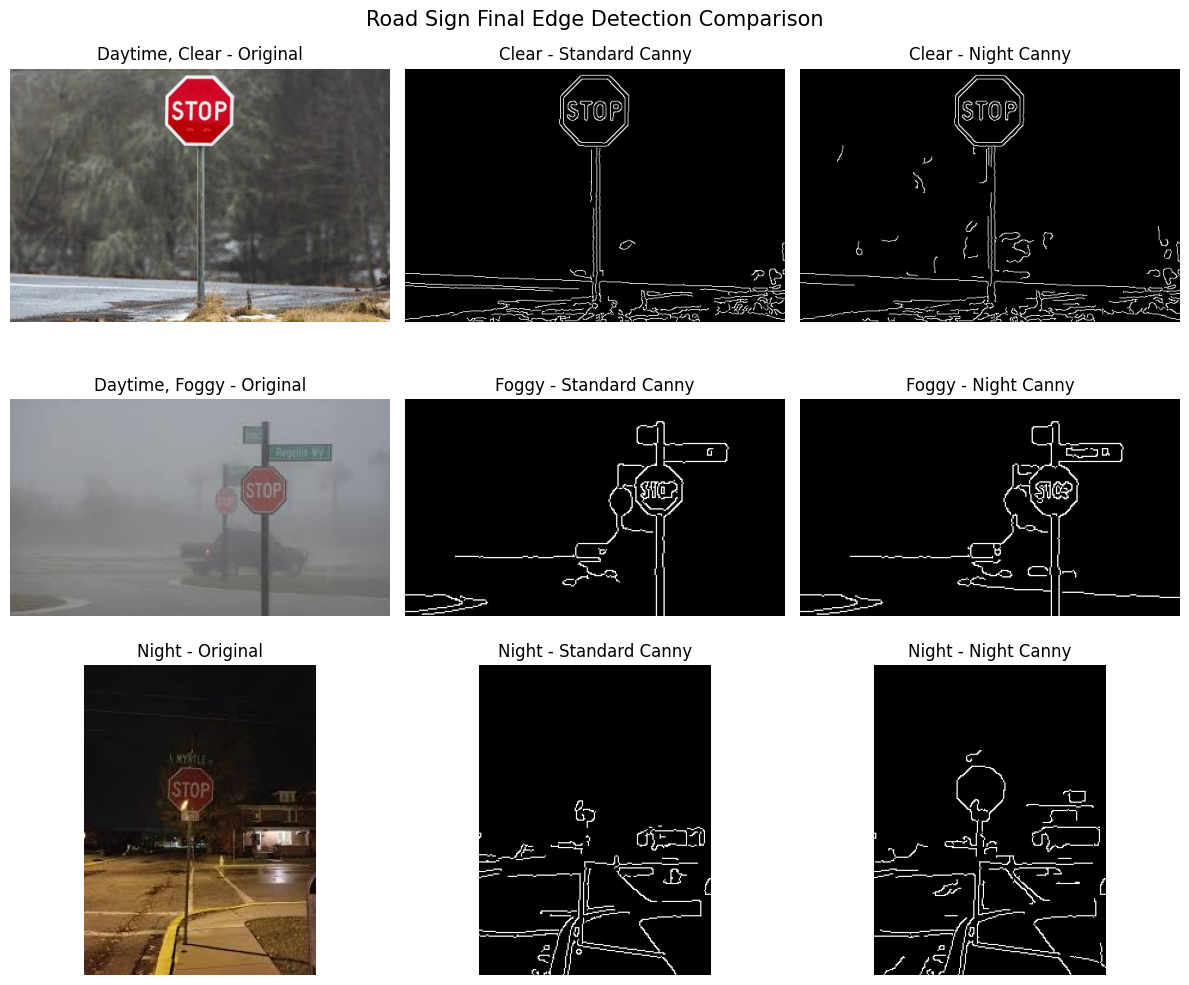

In [14]:
# Please add your code here
# If you do not write your code in this notebook, please attach a link to any code that you wrote!

import numpy as np
import matplotlib.pyplot as plt
from skimage import color, io
import cv2

from edge import gaussian_kernel, conv, gradient, non_maximum_suppression, link_edges

def preprocess(img, low_vis=False):
  # Converts RGB image to grayscale, using condition-specific preprocessing
  # Standard luminance grayscale performed best on daytime images (foggy and clear)
  # For night images, red-channel boosting and moderate CLAHE worked best in dark conditions
    if not low_vis:
        return color.rgb2gray(img.astype(np.float64) / 255.0)

    else:

        r, g, b = (img[:,:,0].astype(np.float64),
                  img[:,:,1].astype(np.float64),
                  img[:,:,2].astype(np.float64))

        # Boosts red to better detect stop signs
        boosted = np.clip(0.65*r + 0.20*g + 0.15*b, 0, 255).astype(np.uint8)
        clahe = cv2.createCLAHE(clipLimit=2.5, tileGridSize=(8, 8))

        return clahe.apply(boosted).astype(np.float64)/255.0


def detect_edges(img, low_vis=False, kernel_size=5, sigma=1.4, high=92, low=75):
    # Run the Canny pipeline from edge.py with adaptive thresholds on an RGB image
    # This means high/low are set as percentiles of NMS values, rather than fixed constants

    gray = preprocess(img, low_vis)
    kernel = gaussian_kernel(kernel_size, sigma)
    smoothed = conv(gray * 255.0, kernel)
    G, theta = gradient(smoothed)
    nms = non_maximum_suppression(G, theta)

    nonzero = nms[nms > 0]
    high = np.percentile(nonzero, high)
    low = np.percentile(nonzero, low)

    strong = nms > high
    weak = (nms <= high) & (nms > low)
    return link_edges(strong, weak)

# Run on images

img_clear = io.imread("clear1.jpeg")
img_fog = io.imread("fog2.jpg")
img_stop = io.imread("stop1.jpg")

# FINAL edge detection output
fig2, axes2 = plt.subplots(3, 3, figsize=(12, 10))
fig2.suptitle("Road Sign Final Edge Detection Comparison", fontsize=15)

# Clear image
axes2[0, 0].imshow(img_clear); axes2[0, 0].set_title("Daytime, Clear - Original")
axes2[0, 1].imshow(detect_edges(img_clear, False), cmap="gray"); axes2[0, 1].set_title("Clear - Standard Canny")
axes2[0, 2].imshow(detect_edges(img_clear, True), cmap="gray"); axes2[0, 2].set_title("Clear - Night Canny")

# Foggy image
axes2[1, 0].imshow(img_fog); axes2[1, 0].set_title("Daytime, Foggy - Original")
axes2[1, 1].imshow(detect_edges(img_fog, False), cmap="gray"); axes2[1, 1].set_title("Foggy - Standard Canny")
axes2[1, 2].imshow(detect_edges(img_fog, True), cmap="gray"); axes2[1, 2].set_title("Foggy - Night Canny")

# Night image
axes2[2, 0].imshow(img_stop); axes2[2, 0].set_title("Night - Original")
axes2[2, 1].imshow(detect_edges(img_stop, False), cmap="gray"); axes2[2, 1].set_title("Night - Standard Canny")
axes2[2, 2].imshow(detect_edges(img_stop, True), cmap="gray"); axes2[2, 2].set_title("Night - Night Canny")

for ax in axes2.flat:
    ax.axis("off")
fig2.tight_layout()
plt.show()

## Writeup (20 points)

An explanation of what you did, and how it relates to the topic of choice. (~200 words) Please attach any images, figures, etc.

_You may also add a link to your writeup if that is easier!_

**Writeup:**



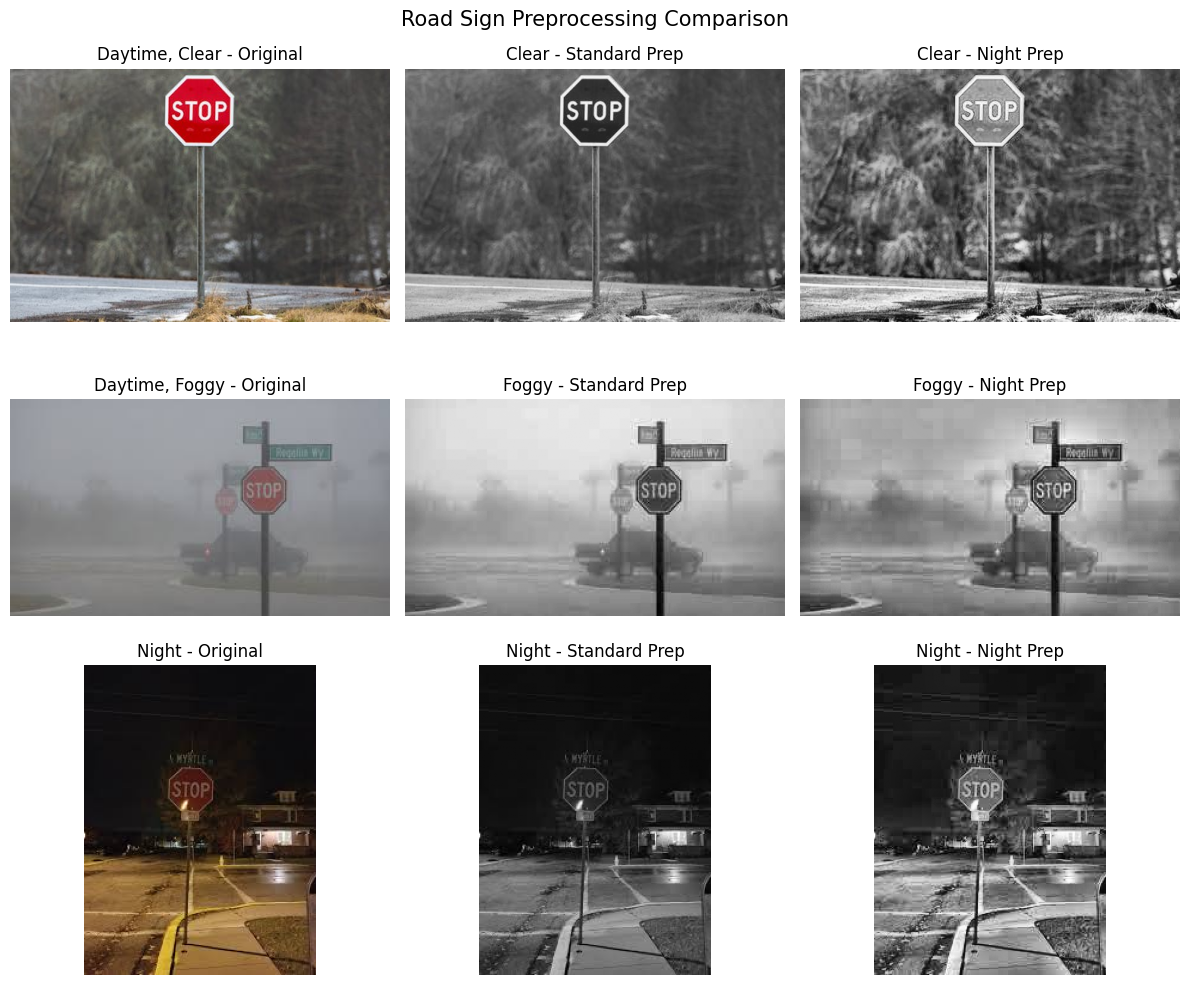

In [15]:
# INTERMEDIATE edge detection (after preprocessing)
fig1, axes1 = plt.subplots(3, 3, figsize=(12, 10))
fig1.suptitle("Road Sign Preprocessing Comparison", fontsize=15)

# Clear image
axes1[0, 0].imshow(img_clear); axes1[0, 0].set_title("Daytime, Clear - Original")
axes1[0, 1].imshow(preprocess(img_clear, False), cmap="gray"); axes1[0, 1].set_title("Clear - Standard Prep")
axes1[0, 2].imshow(preprocess(img_clear, True), cmap="gray"); axes1[0, 2].set_title("Clear - Night Prep")

# Foggy image
axes1[1, 0].imshow(img_fog); axes1[1, 0].set_title("Daytime, Foggy - Original")
axes1[1, 1].imshow(preprocess(img_fog, False), cmap="gray"); axes1[1, 1].set_title("Foggy - Standard Prep")
axes1[1, 2].imshow(preprocess(img_fog, True), cmap="gray"); axes1[1, 2].set_title("Foggy - Night Prep")

# Night image
axes1[2, 0].imshow(img_stop); axes1[2, 0].set_title("Night - Original")
axes1[2, 1].imshow(preprocess(img_stop, False), cmap="gray"); axes1[2, 1].set_title("Night - Standard Prep")
axes1[2, 2].imshow(preprocess(img_stop, True), cmap="gray"); axes1[2, 2].set_title("Night - Night Prep")

for ax in axes1.flat:
    ax.axis("off")
fig1.tight_layout()